In [294]:
import pandas as pd

In [295]:
ipl=pd.read_csv("../data/raw/ipl.csv")

C:\Users\SRIHARSHITH\AppData\Local\Temp\ipykernel_24664\2783825913.py:1: DtypeWarning: Columns (28,29,30,31,43,46,47,48,51) have mixed types. Specify dtype option on import or set low_memory=False.
  ipl=pd.read_csv("../data/raw/ipl.csv")


In [296]:
ipl.head()

,Unnamed: 0,match_id,date,match_type,event_name,innings,batting_team,bowling_team,over,ball,...,team_balls,team_wicket,new_batter,power_surge_start,batter_runs,batter_balls,bowler_wicket,batting_partners,next_batter,striker_out
0,141607,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,1,...,1,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
1,141608,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,2,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
2,141609,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,2,0,NaN,NaN,0,1,0,"('BB McCullum', 'SC Ganguly')",NaN,False
3,141610,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,3,...,3,0,NaN,NaN,0,2,0,"('BB McCullum', 'SC Ganguly')",NaN,False
4,141611,335982,2008-04-18,T20,Indian Premier League,1,Kolkata Knight Riders,Royal Challengers Bangalore,0,4,...,4,0,NaN,NaN,0,3,0,"('BB McCullum', 'SC Ganguly')",NaN,False


In [297]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 283678 entries, 0 to 283677
Data columns (total 65 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   Unnamed: 0         283678 non-null  int64  
 1   match_id           283678 non-null  int64  
 2   date               283678 non-null  object 
 3   match_type         283678 non-null  object 
 4   event_name         283678 non-null  object 
 5   innings            283678 non-null  int64  
 6   batting_team       283678 non-null  object 
 7   bowling_team       283678 non-null  object 
 8   over               283678 non-null  int64  
 9   ball               283678 non-null  int64  
 10  ball_no            283678 non-null  float64
 11  batter             283678 non-null  object 
 12  bat_pos            283678 non-null  int64  
 13  runs_batter        283678 non-null  int64  
 14  balls_faced        283678 non-null  int64  
 15  bowler             283678 non-null  object 
 16  va

In [298]:
ipl.shape

(283678, 65)

In [299]:
drop_cols = [
    "Unnamed: 0",        
    "event_name",        
    "gender",           
    "team_type",      
    "balls_per_over",   
    "overs",            
    "review_batter",    
    "team_reviewed",    
    "review_decision",  
    "umpire",           
    "umpires_call",     
    "power_surge_start", 
    "new_batter",        
    "next_batter",       
    "fielders"           
]

In [300]:
ipl.drop(columns=drop_cols, inplace=True)

Basically two tasks are performed

1)Match winner prediction

2)live probability prediction


In [301]:
winner_features = [
    "match_id",
    "date",
    "batting_team",
    "bowling_team",
    "toss_winner",
    "toss_decision",
    "venue",
    "city",
    "season",
    "stage",
    "match_won_by",
    "player_of_match"
]


In [302]:
live_probability_features = [
    "match_id",
    "innings",
    "team_runs",
    "team_balls",
    "team_wicket",
    "runs_target",
    "batting_team",
    "bowling_team",
    "venue",
    "over",
    "ball"
]

In [303]:
df1=ipl[winner_features].copy()
df2=ipl[live_probability_features].copy()

In [304]:
df1.head()

,match_id,date,batting_team,bowling_team,toss_winner,toss_decision,venue,city,season,stage,match_won_by,player_of_match
0,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,Unknown,Kolkata Knight Riders,BB McCullum
1,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,Unknown,Kolkata Knight Riders,BB McCullum
2,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,Unknown,Kolkata Knight Riders,BB McCullum
3,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,Unknown,Kolkata Knight Riders,BB McCullum
4,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,Unknown,Kolkata Knight Riders,BB McCullum


In [305]:
df1['stage']=df1['stage'].replace('Unknown','group stage')
df1.head()


,match_id,date,batting_team,bowling_team,toss_winner,toss_decision,venue,city,season,stage,match_won_by,player_of_match
0,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum
1,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum
2,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum
3,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum
4,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum


In [306]:
df2.head()

,match_id,innings,team_runs,team_balls,team_wicket,runs_target,batting_team,bowling_team,venue,over,ball
0,335982,1,1,1,0,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,0,1
1,335982,1,1,2,0,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,0,2
2,335982,1,2,2,0,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,0,3
3,335982,1,2,3,0,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,0,3
4,335982,1,2,4,0,NaN,Kolkata Knight Riders,Royal Challengers Bangalore,M Chinnaswamy Stadium,0,4


In [307]:
df2['runs_target']=df2['runs_target'].fillna(0)
##Because the target runs is only available for second innings, we can fill the missing values with 0 for first innings

In [308]:
df1.head()

,match_id,date,batting_team,bowling_team,toss_winner,toss_decision,venue,city,season,stage,match_won_by,player_of_match
0,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum
1,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum
2,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum
3,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum
4,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bangalore,Royal Challengers Bangalore,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum


In [309]:
df1.loc[
    df1['venue'] == 'M.Chinnaswamy Stadium',
    'venue'
] = 'M Chinnaswamy Stadium'
df2.loc[
    df2['venue'] == 'M.Chinnaswamy Stadium',
    'venue'
] = 'M Chinnaswamy Stadium'

team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}
cols_to_update = [
    'batting_team',
    'bowling_team',
    'match_won_by',
    'toss_winner'
]
columns_to_update = [
    'batting_team',
    'bowling_team'
]
df1[cols_to_update] = df1[cols_to_update].replace(team_mapping)
df2[columns_to_update] = df2[columns_to_update].replace(team_mapping)

In [310]:
match = df1.groupby('match_id', as_index=False).agg({
    'date': 'first',
    'batting_team': 'first',
    'bowling_team': 'first',
    'toss_winner': 'first',
    'toss_decision': 'first',
    'venue': 'first',
    'city': 'first',
    'season': 'first',
    'stage': 'first',
    'match_won_by': 'first',
    'player_of_match': 'first'
})
match=match[match['match_won_by']!='Unknown']
match.head()

,match_id,date,batting_team,bowling_team,toss_winner,toss_decision,venue,city,season,stage,match_won_by,player_of_match
0,335982,2008-04-18,Kolkata Knight Riders,Royal Challengers Bengaluru,Royal Challengers Bengaluru,field,M Chinnaswamy Stadium,Bangalore,2007/08,group stage,Kolkata Knight Riders,BB McCullum
1,335983,2008-04-19,Chennai Super Kings,Punjab Kings,Chennai Super Kings,bat,"Punjab Cricket Association Stadium, Mohali",Chandigarh,2007/08,group stage,Chennai Super Kings,MEK Hussey
2,335984,2008-04-19,Rajasthan Royals,Delhi Capitals,Rajasthan Royals,bat,Feroz Shah Kotla,Delhi,2007/08,group stage,Delhi Capitals,MF Maharoof
3,335985,2008-04-20,Mumbai Indians,Royal Challengers Bengaluru,Mumbai Indians,bat,Wankhede Stadium,Mumbai,2007/08,group stage,Royal Challengers Bengaluru,MV Boucher
4,335986,2008-04-20,Deccan Chargers,Kolkata Knight Riders,Deccan Chargers,bat,Eden Gardens,Kolkata,2007/08,group stage,Kolkata Knight Riders,DJ Hussey


This is done to see the team performance in ipl

In [311]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0.5, 1.0, 'Number of Matches Won by Each Team')

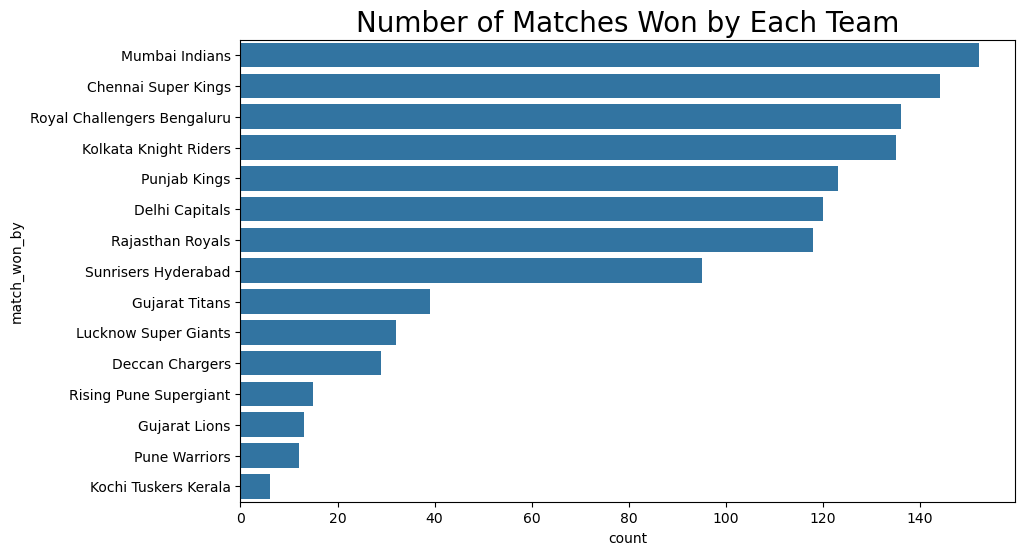

In [312]:
plt.figure(figsize=(10,6))
wins = match['match_won_by'].value_counts()
sns.countplot(
    data=match,
    y='match_won_by',
    order=wins.index,
)
plt.title('Number of Matches Won by Each Team', fontsize=20)

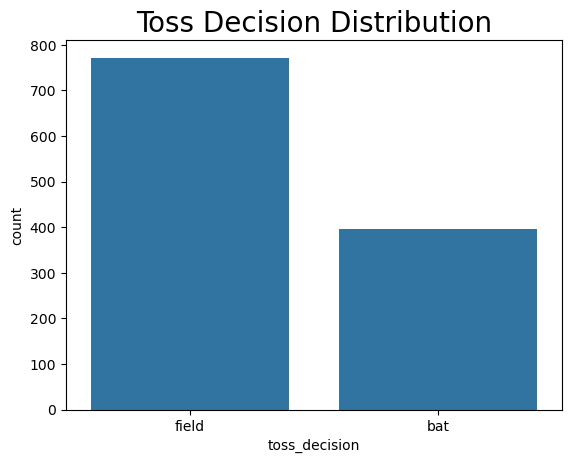

In [313]:
sns.countplot(data=match,x='toss_decision')
plt.title('Toss Decision Distribution', fontsize=20)
plt.show()

In [314]:
match['toss_helped'] = match['toss_winner'] == match['match_won_by']
match['toss_helped'].value_counts(normalize=True)*100

toss_helped
True     51.839179
False    48.160821
Name: proportion, dtype: float64

There is almost 50-50 percent that toss has helped the teams

In [315]:
match['venue'] = match['venue'].apply(
    lambda x: x.split(',')[0].strip()
)

In [316]:
match['toss_helped'] = (
    match['toss_winner'] == match['match_won_by']
).astype(int)
decision_stats = (
    match.groupby(['venue', 'toss_decision'])['toss_helped']
    .mean()
    .reset_index()
)
best_toss_decision_at_stadium = decision_stats.loc[
    decision_stats.groupby('venue')['toss_helped'].idxmax()
]
best_toss_decision_at_stadium['toss_helped'] = (
    best_toss_decision_at_stadium['toss_helped'] * 100
).round(2)
best_toss_decision_at_stadium

,venue,toss_decision,toss_helped
0,Arun Jaitley Stadium,bat,54.55
2,Barabati Stadium,bat,100.00
5,Barsapara Cricket Stadium,field,42.86
7,Bharat Ratna Shri Atal Bihari Vajpayee Ekana C...,field,70.59
8,Brabourne Stadium,bat,55.56
10,Buffalo Park,bat,66.67
12,De Beers Diamond Oval,field,100.00
14,Dr DY Patil Sports Academy,field,55.56
16,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,field,55.56
18,Dubai International Cricket Stadium,field,44.00


Per stadium the good toss decision with the winning percent for that call

In [317]:
stage_mapping = {
    'group stage': 'League',
    'Semi Final': 'Playoffs',
    'Qualifier 1': 'Playoffs',
    'Qualifier 2': 'Playoffs',
    'Eliminator': 'Playoffs',
    'Elimination Final': 'Playoffs',
    '3rd Place Play-Off': 'Other',
    'Final': 'Final'
}

match['stage_clean'] = match['stage'].replace(stage_mapping)

<Axes: ylabel='match_won_by'>

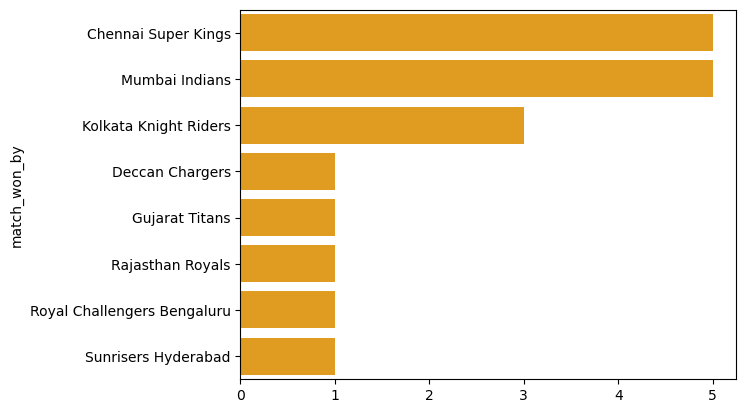

In [370]:
data1=match.groupby('stage_clean')['match_won_by'].value_counts()['Final']
sns.barplot(y=data1.index, x=data1.values,color='orange')

Most trophies are won by Chennai Super Kings and Mumbai Indians


<Axes: ylabel='match_won_by'>

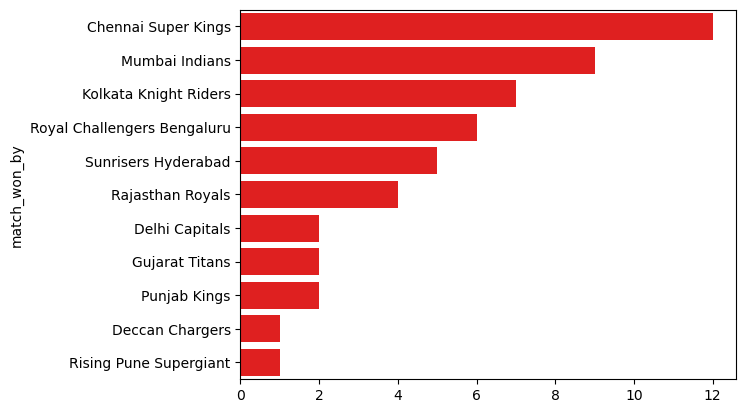

In [372]:
data2=match.groupby('stage_clean')['match_won_by'].value_counts()['Playoffs']
sns.barplot(y=data2.index, x=data2.values,color='red')

Playoffs played by each team.The plots show csk has been a successful franchise

In [320]:
df2.head()

,match_id,innings,team_runs,team_balls,team_wicket,runs_target,batting_team,bowling_team,venue,over,ball
0,335982,1,1,1,0,0.0,Kolkata Knight Riders,Royal Challengers Bengaluru,M Chinnaswamy Stadium,0,1
1,335982,1,1,2,0,0.0,Kolkata Knight Riders,Royal Challengers Bengaluru,M Chinnaswamy Stadium,0,2
2,335982,1,2,2,0,0.0,Kolkata Knight Riders,Royal Challengers Bengaluru,M Chinnaswamy Stadium,0,3
3,335982,1,2,3,0,0.0,Kolkata Knight Riders,Royal Challengers Bengaluru,M Chinnaswamy Stadium,0,3
4,335982,1,2,4,0,0.0,Kolkata Knight Riders,Royal Challengers Bengaluru,M Chinnaswamy Stadium,0,4


In [377]:
final_score=df2[(df2['innings']<=2) & (df2['innings']>0) & (df2['team_balls']>7)].groupby(['match_id', 'innings']).last().reset_index()
final_score.head()

,match_id,innings,team_runs,team_balls,team_wicket,runs_target,batting_team,bowling_team,venue,over,ball
0,335982,1,222,120,3,0.0,Kolkata Knight Riders,Royal Challengers Bengaluru,M Chinnaswamy Stadium,19,6
1,335982,2,82,91,10,223.0,Royal Challengers Bengaluru,Kolkata Knight Riders,M Chinnaswamy Stadium,15,1
2,335983,1,240,120,5,0.0,Chennai Super Kings,Punjab Kings,"Punjab Cricket Association Stadium, Mohali",19,6
3,335983,2,207,120,4,241.0,Punjab Kings,Chennai Super Kings,"Punjab Cricket Association Stadium, Mohali",19,6
4,335984,1,129,120,8,0.0,Rajasthan Royals,Delhi Capitals,Feroz Shah Kotla,19,6


In [350]:
final_score.groupby('batting_team')['team_runs'].mean().sort_values(ascending=False).head(10).reset_index().rename(columns={'team_runs':'avg_runs_scored'}).sort_values(by='avg_runs_scored',ascending=False)

,batting_team,avg_runs_scored
0,Gujarat Titans,177.968750
1,Lucknow Super Giants,175.158730
2,Chennai Super Kings,164.093750
3,Mumbai Indians,163.017730
4,Sunrisers Hyderabad,162.855000
5,Punjab Kings,162.727612
6,Gujarat Lions,161.866667
7,Royal Challengers Bengaluru,161.587591
8,Rajasthan Royals,159.682008
9,Delhi Capitals,156.881481


The average batting score is highest for gujarat titans and least for Delhi Capitals

In [351]:
final_score.groupby('bowling_team')['team_wicket'].mean().sort_values(ascending=False).head(10).reset_index().rename(columns={'team_wicket':'avg_wickets_taken'}).sort_values(by='avg_wickets_taken',ascending=False)

,bowling_team,avg_wickets_taken
0,Gujarat Titans,6.468750
1,Rising Pune Supergiant,6.300000
2,Chennai Super Kings,6.182879
3,Mumbai Indians,6.095745
4,Deccan Chargers,5.946667
5,Sunrisers Hyderabad,5.940299
6,Delhi Capitals,5.936567
7,Lucknow Super Giants,5.935484
8,Royal Challengers Bengaluru,5.908759
9,Kolkata Knight Riders,5.843284


Avg wickets taken is highest for Gujarat titans and least for KKR

In [352]:
final_score.groupby('venue')['team_runs'].mean().sort_values(ascending=False).head(10).reset_index().rename(columns={'team_runs':'avg_runs_scored'}).sort_values(by='avg_runs_scored',ascending=False)

,venue,avg_runs_scored
0,Maharaja Yadavindra Singh International Cricke...,200.833333
1,Dr. Y.S. Rajasekhara Reddy ACA-VDCA Cricket St...,193.625000
2,"Arun Jaitley Stadium, Delhi",191.120000
3,"Himachal Pradesh Cricket Association Stadium, ...",188.363636
4,"Eden Gardens, Kolkata",186.680000
5,"Punjab Cricket Association IS Bindra Stadium, ...",185.600000
6,"M Chinnaswamy Stadium, Bengaluru",185.568182
7,"Rajiv Gandhi International Stadium, Uppal, Hyd...",184.487805
8,"Sawai Mansingh Stadium, Jaipur",179.264706
9,"Narendra Modi Stadium, Ahmedabad",179.205882


In [362]:
final_score.groupby('batting_team')['team_runs'].agg(['max']).sort_values(by='max',ascending=False)

,max
batting_team,
Sunrisers Hyderabad,287
Kolkata Knight Riders,272
Royal Challengers Bengaluru,263
Punjab Kings,262
Delhi Capitals,257
Lucknow Super Giants,257
Mumbai Indians,247
Chennai Super Kings,246
Rajasthan Royals,242


Highest team score is by Sunrisers Hyderabad


In [367]:
match.groupby('player_of_match').size().sort_values(ascending=False).head(10).reset_index().rename(columns={0:'count'}).sort_values(by='count',ascending=False)

,player_of_match,count
0,AB de Villiers,24
1,CH Gayle,22
2,RG Sharma,21
3,V Kohli,18
4,DA Warner,18
5,MS Dhoni,18
6,SP Narine,17
7,AD Russell,16
8,RA Jadeja,16
9,SR Watson,16


Most of the player of the match awards received by AB de Villiers

<Axes: xlabel='team_runs', ylabel='Count'>

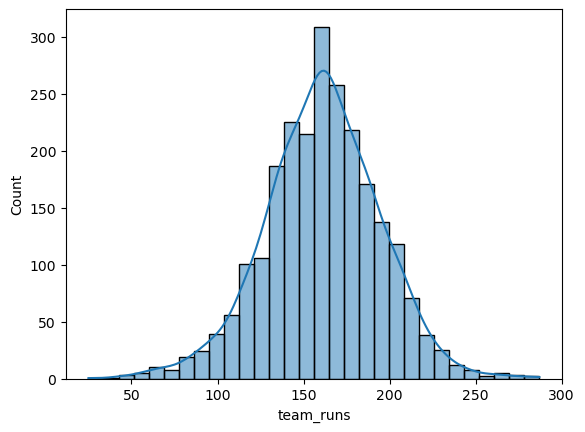

In [376]:
sns.histplot(final_score['team_runs'], bins=30, kde=True)

Average batting score of ipl is around 160

In [ ]:
match_data=match[winner_features]


In [383]:
live_df = df2[df2['innings'] == 2].copy()
live_df['runs_left'] = (
    live_df['runs_target'] - live_df['team_runs']
)
live_df['balls_left'] = (
    120 - live_df['team_balls']
)
live_df['wickets_left'] = (
    10 - live_df['team_wicket']
)
live_df['current_rr'] = (
    live_df['team_runs'] * 6
) / live_df['team_balls']
live_df['required_rr'] = (
    live_df['runs_left'] * 6
) / live_df['balls_left']
live_df = live_df[
    (live_df['balls_left'] > 0)
    &
    (live_df['runs_left'] >= 0)
]

In [384]:
match_data.to_csv('../data/processed/match_data.csv', index=False)
best_toss_decision_at_stadium.to_csv("../data/processed/best_toss_decision.csv",index=False)
live_df.to_csv( "../data/processed/live_data.csv",index=False)